In [5]:
using Symbolics, Latexify

In [7]:
@variables x

1-element Vector{Num}:
 x

In [8]:
P0 = Num(1)

1

In [9]:
P1 = x

x

In [12]:
P2 = (Num(2)*Num(2)-Num(1))/Num(2)*x*P1 - (Num(2)-Num(1))/Num(2)*P0

-(1//2) + (3//2)*(x^2)

In [19]:
dP2 = Symbolics.derivative(P2,x)

(3//1)*x

In [15]:
P3 = expand((Num(2)*Num(3)-Num(1))/Num(3)*x*P2 - (Num(3)-Num(1))/Num(3)*P1)

-(3//2)*x + (5//2)*(x^3)

In [21]:
substitute(P3, x=>1), substitute(dP3, x=> sqrt(Num(3)/Num(5)))

(1//1, 3.0)

In [20]:
dP3 = Symbolics.derivative(P3,x)

-(3//2) + (15//2)*(x^2)

In [22]:
substitute(dP3, x =>sqrt(Num(3)/Num(5)))

3.0

In [25]:
substitute(2/((1-x^2)*(dP3)^2), x => sqrt(Num(3)/Num(5)))

0.5555555555555556

In [26]:
substitute(2/((1-x^2)*(dP3)^2), x => 0)

8//9

In [27]:
P7(x) = (429*x^7-693*x^5+315*x^3-35*x)/16
dP7(x) = (7*429*x^6-5*693*x^4+945*x^2-35)/16

dP7 (generic function with 1 method)

## Finding Roots of Gaussian Quadrature $n=7$

In [84]:
using MultiFloats, CairoMakie, PrettyTables, SpecialFunctions
CairoMakie.activate!()
Makie.inline!(true)

true

In [28]:
function iterate(f::Function, x0::Real; tol=1e-8, maxiter=100)
  x = Vector{typeof(x0)}()
  push!(x, x0)
  for i = 2:maxiter
    push!(x, f(x[end]))
    abs(x[end-1] - x[end]) < tol && return x
  end
  @warn "Maximum iterations reached"
  x
end

iterate (generic function with 1 method)

In [30]:
function newton(f::Function, df::Function, x0::Real; tol=1e-8, maxiter = 20)
  iterate(x-> x-f(x)/df(x), x0; tol = tol, maxiter = maxiter)
end

newton (generic function with 1 method)

In [31]:
newton(x->x^2-5, x->2x, Float64x2(1.0), tol=1e-40)

9-element Vector{MultiFloat{Float64, 2}}:
 1.0
 3.0
 2.33333333333333333333333333333334
 2.238095238095238095238095238095216
 2.23606889564336372847011144883486
 2.23606797749997819409459355858146
 2.23606797749978969640917367667633
 2.23606797749978969640917366873127
 2.23606797749978969640917366873127

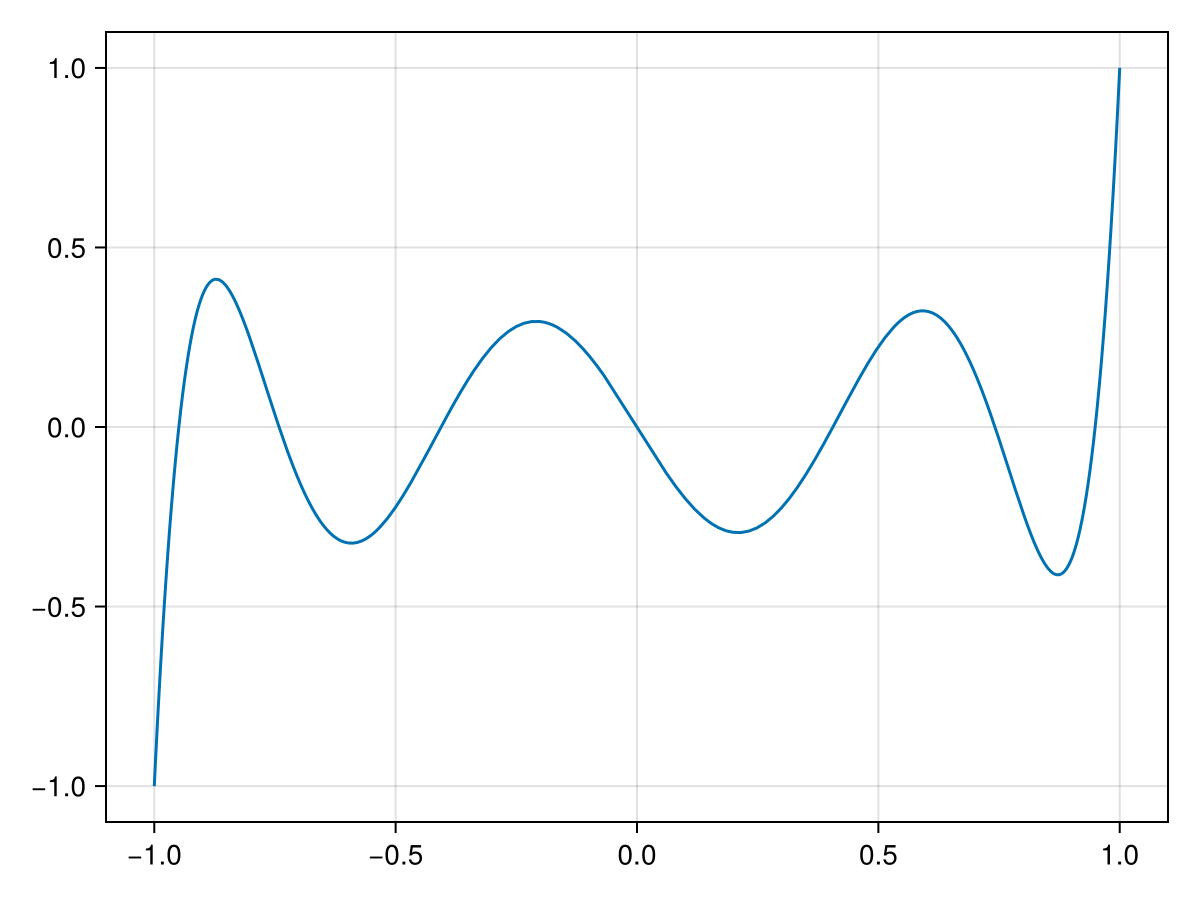

In [41]:
lines(-1..1,P7)

In [42]:
root1 = newton(P7, dP7, Float64x3(1.0), tol = 1e-40)

9-element Vector{MultiFloat{Float64, 3}}:
 1.0
 0.9642857142857142857142857142857142857142857142858
 0.95095973614620545916558085161031488009138022469314
 0.9491399770632092234092998108941486870312647559534
 0.949107922176281200270143592172539511755362101193
 0.9491079123427594497517803442567726379643470779524
 0.949107912342758524526189684056042032111456186088
 0.9491079123427585245261896840478512624007709376688
 0.9491079123427585245261896840478512624007709376688

In [43]:
root2 = newton(P7, dP7, Float64x3(0.8), tol = 1e-40)

8-element Vector{MultiFloat{Float64, 3}}:
 0.8000000000000000444089209850062616169452667236328125
 0.7383985185901106906934728293249302709581590813212248
 0.74154853030922572653984791596224041852766271269193
 0.74153118609478700252257099870617023231956498513154
 0.741531185599394440268151025406077353548951364073
 0.7415311855993944398638647732807884073434052408917
 0.741531185599394439863864773280788407074147647141
 0.741531185599394439863864773280788407074147647141

In [44]:
root3 = newton(P7, dP7, Float64x3(0.5), tol = 1e-40)

8-element Vector{MultiFloat{Float64, 3}}:
 0.5
 0.38704893722194760257043994068215521502718734552645
 0.40616097218560613511840885281465440824986399987477
 0.4058451991659638258185743495233012307926950874697
 0.40584515137739827651651084794133662417525249515077
 0.4058451513773971669066064120775596874103621851422
 0.4058451513773971669066064120769614633473820140989
 0.4058451513773971669066064120769614633473820140994

In [45]:
leg_roots = [-root1[end],-root2[end],-root3[end],0,root3[end],root2[end],root1[end]]

7-element Vector{MultiFloat{Float64, 3}}:
 -0.9491079123427585245261896840478512624007709376688
 -0.741531185599394439863864773280788407074147647141
 -0.4058451513773971669066064120769614633473820140994
 0.0
 0.4058451513773971669066064120769614633473820140994
 0.741531185599394439863864773280788407074147647141
 0.9491079123427585245261896840478512624007709376688

In [46]:
P7sym = (429*x^7-693*x^5+315*x^3-35*x)/16

(-35x + 315(x^3) - 693(x^5) + 429(x^7)) / 16

In [48]:
dP7sym = Symbolics.derivative(P7sym,x)

(-35 + 945(x^2) - 3465(x^4) + 3003(x^6)) / 16

In [56]:
w = eval(build_function(2/((1-x^2)*dP7sym^2),x))

#49 (generic function with 1 method)

In [59]:
weights = w.(leg_roots)

7-element Vector{MultiFloat{Float64, 3}}:
 0.1294849661688696932706114326790820183285874022633
 0.27970539148927666790146777142377958248692506522643
 0.3818300505051189449503697754889751338783650835334
 0.4179591836734693877551020408163265306122448979591
 0.3818300505051189449503697754889751338783650835334
 0.27970539148927666790146777142377958248692506522643
 0.1294849661688696932706114326790820183285874022633

In [96]:
dP7(x) = 2*16^2/((1-x^2)*(-35+945x^2-3465*x^4+3003x^6)^2)

dP7 (generic function with 1 method)

In [97]:
dP7.(leg_roots)

7-element Vector{MultiFloat{Float64, 3}}:
 0.1294849661688696932706114326790820183285874022633
 0.27970539148927666790146777142377958248692506522643
 0.3818300505051189449503697754889751338783650835334
 0.4179591836734693877551020408163265306122448979591
 0.3818300505051189449503697754889751338783650835334
 0.27970539148927666790146777142377958248692506522643
 0.1294849661688696932706114326790820183285874022633

In [64]:
round(leg_roots[3]^2,digits=8)

0.16471029

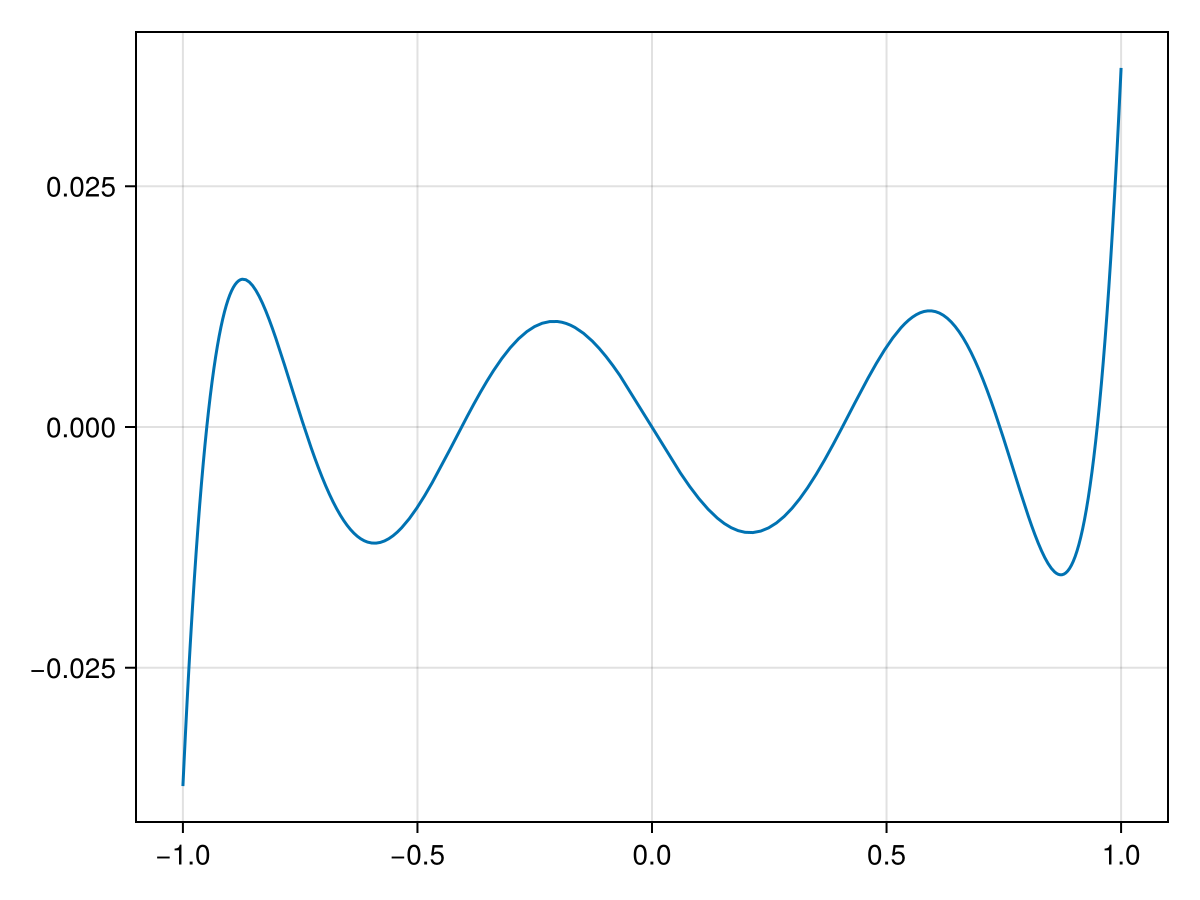

In [67]:
fig = lines(-1..1, x-> x*(x^2-0.90080583)*(x^2-0.5498685)*(x^2-0.16471029))

In [69]:
save("../../assets/plots/gauss7.png", fig)

In [78]:
pretty_table(hcat(1:7,leg_roots, weights); column_labels = ["i", "x_i", "w_i"], formatters = [fmt__printf("%22.20f", [2,3])])

┌─────┬─────────────────────────┬────────────────────────┐
│   i │                     x_i │                    w_i │
├─────┼─────────────────────────┼────────────────────────┤
│ 1.0 │ -0.94910791234275852453 │ 0.12948496616886969327 │
│ 2.0 │ -0.74153118559939443986 │ 0.27970539148927666790 │
│ 3.0 │ -0.40584515137739716691 │ 0.38183005050511894495 │
│ 4.0 │  0.00000000000000000000 │ 0.41795918367346938776 │
│ 5.0 │  0.40584515137739716691 │ 0.38183005050511894495 │
│ 6.0 │  0.74153118559939443986 │ 0.27970539148927666790 │
│ 7.0 │  0.94910791234275852453 │ 0.12948496616886969327 │
└─────┴─────────────────────────┴────────────────────────┘


In [79]:
g(x) = exp(-x^2)

g (generic function with 1 method)

In [89]:
i7 = sum(weights.*g.(leg_roots))

1.493648288869413932116332983071763448257828430285

In [98]:
sum(dP7.(leg_roots) .* g.(leg_roots))

1.493648288869413932116332983071763448257828430285

In [88]:
erf(big(1.0))*sqrt(big(pi))

1.493648265624854050798934872263706010708999373625212658055308997917210655123528

In [90]:
abs(i7-erf(big(1.0))*sqrt(big(pi)))

2.324455988131739811080805743754882905665994466836744412601101325190681314523908e-8

In [92]:
using FastGaussQuadrature

In [93]:
nodes7, weights7 = gausslegendre(7)

([-0.9491079123427586, -0.7415311855993945, -0.4058451513773972, 0.0, 0.4058451513773972, 0.7415311855993945, 0.9491079123427586], [0.1294849661688702, 0.2797053914892766, 0.3818300505051189, 0.4179591836734694, 0.3818300505051189, 0.2797053914892766, 0.1294849661688702])

In [101]:
sum(weights7.*g.(nodes7))

1.493648288869414

In [102]:
sum(weights.*g.(nodes7)) - erf(big(1.0))*sqrt(big(pi))

2.32445599107514674284440310663595616078670137246636314535499313110967754339374e-8

In [107]:
0.5*sum(weights.*(g.(0.5 .+ 0.5*leg_roots)))

0.74682413281163830879066365158970566029061459717517

In [113]:
0.5*sum(weights.*(g.(0.5 .+ 0.5*leg_roots))) -erf(big(1.0))*sqrt(big(pi))/2

-7.88716608803784542147345063885089637433274214607231946382078943300942978833478e-13